# Optimization Using ML Models

In this notebook we optimize the cross section using ML models for all kinds of tasks. The only calculation not done by ML models is the calculation of the response of the beam, for which we use a Fourier solution.

In [14]:
from typing import Iterable
from numbers import Number
import json

from sigmaepsilon.math.optimize import BinaryGeneticAlgorithm as BGA
from sigmaepsilon.solid.fourier import NavierBeam, LoadGroup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from tqdm import tqdm

from utils import (
    INTERNAL_FORCE_COMPONENTS,
    CROSS_SECTION_PARAMETERS,
    print_system_info,
)
from utils.ml import get_best_model, get_predictor_columns
from utils.loads import get_loads_from_config
from utils.section import construct_section, utilization, section_properties

print_system_info()

Python version: 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
Operating System: Darwin 23.4.0
Platform: macOS-14.4-arm64-arm-64bit
Processor: arm
Machine: arm64
CPU count: 11


In [15]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
mlflow_tracking_uri = "sqlite:///mlflow.db"

In [16]:
# Load configuration file into a dictionary
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

# Extract section data from config
section_data: dict = config["section"]
section_type: str = section_data["type"]
print(f"Section type from config: {section_type}")
        
# Collect data about section parameters
section_variables: list[str] = []     # list of variable parameters
section_params: list[str] = []        # list of all parameters, including fixed ones
section_variable_ranges = []          # list of ranges for variable parameters
section_variable_default_values = []  # list of default values for variable parameters
for p in section_data["params"]:
    section_params.append(p)
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        section_variable_default_values.append(section_data["params"][p]["default"])
        section_variable_ranges.append(section_data["params"][p]["range"])
default_section_params = {p:section_data["params"][p]["default"] for p in section_params}

# Extract loads from config
beam_loads: LoadGroup = get_loads_from_config(config)

# Define other parameters
beam_length = config["beam"]["length"]  # mm
number_of_modes = config["calculation"]["number_of_modes"]
num_evaluation_points = config["calculation"]["num_evaluation_points"]

# Set up points of evaluation along the beam length
evaluation_points = np.linspace(0, beam_length, num_evaluation_points)

# Set up MLflow tracking URI
mlflow.set_tracking_uri(mlflow_tracking_uri)

Section type from config: rectangular_hollow_section


In [ ]:
tasks = ["failure_prediction", "utilization_estimation", "section_estimation", "geometry_validation"]
tasks = {task: dict() for task in tasks}

for task in tasks:
    predictor_columns = get_predictor_columns(config, task)
    best_model = get_best_model(config, data_file_path, task, section_type, test=True, flavour="sklearn")
    tasks[task] = {
        "model": best_model, 
        "predictor_columns": predictor_columns
    }

## Optimize

### Set the objective

In [18]:
def objective(input: Iterable[Number], *, penalty:float=1e12) -> float:    
    model = tasks["geometry_validation"]["model"]
    is_valid_geometry = model.predict(input)[0] == 1
    if not is_valid_geometry:
        return 2*penalty

    model = tasks["section_estimation"]["model"]
    output = model.predict(input)
    df = pd.DataFrame(output, columns=CROSS_SECTION_PARAMETERS)
    bending_stiffness = df["ixx"].values[0]
    area = df["area"].values[0]

    bernoulli_beam = NavierBeam(beam_length, number_of_modes, EI=bending_stiffness)
    analysis_results = bernoulli_beam.linear_static_analysis(evaluation_points, beam_loads)
    df = pd.concat([v.to_pandas()[["MZ", "SY"]] for v in analysis_results.values(deep=True)], ignore_index=True)
    df.columns = ["mxx", "vy"]
    for comp in ["n", "myy", "vx", "mzz"]:
        df[comp] = 0.0
    for k, v in zip(section_variables, input):
        df[k] = v
    df = df[section_variables + INTERNAL_FORCE_COMPONENTS]

    # model = tasks["utilization_estimation"]["model"]
    # utilization = model.predict(df)
    # max_utilization = utilization.max()
    # has_failure = max_utilization > 1.0

    model = tasks["failure_prediction"]["model"]
    failure_prediction = model.predict(df)
    has_failure = failure_prediction.max() > 0.5

    result = area
    if has_failure:
        return penalty

    return result


objective([100, 100, 6, 15]), objective([120, 120, 12, 15])

(2109.5943858746505, 4970.687049981421)

### Preliminary optimization with a binary genetic algorithm

Initial fitness: 1283.6136


Epoch 49/49 | Fitness: 931.9109: 100%|██████████| 49/49 [06:22<00:00,  7.81s/it] 


✅ Optimization finished. Fitness: 931.9109


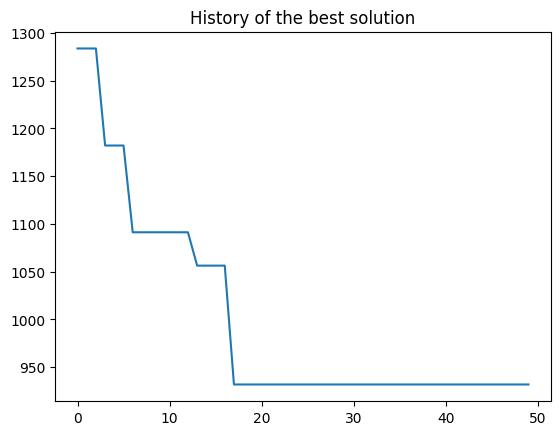

In [ ]:
bga = BGA(objective, section_variable_ranges, length=8, nPop=100, minimize=True)

history = [objective(bga.best_phenotype())]

n_iter_bga = 100
bga.evolve(1)
n_iter_bga -= 1
fittness = bga.champion.fittness
tqdm.write(f"Initial fitness: {fittness:.4f}")
pbar = tqdm(total=n_iter_bga)
for epoch in range(n_iter_bga):
    bga.evolve(1)
    fittness = bga.champion.fittness
    history.append(fittness)
    pbar.set_description(
        f"Epoch {epoch+1}/{n_iter_bga} | "
        f"Fitness: {fittness:.4f}"
    )
    pbar.update(1)
pbar.close()

x = bga.champion.phenotype
fx = bga.champion.fittness
tqdm.write(f"✅ Optimization finished. Fitness: {fx:.4f}")

bga_solution = default_section_params.copy()
bga_solution.update({k: v for k, v in zip(section_variables, x)})

plt.plot(history)
plt.title('History of the best solution')
plt.show()

### Tighten with SciPy

In [ ]:
from scipy.optimize import OptimizeResult, minimize as scipy_minimize
import warnings


def scipy_objective(x: Iterable[Number]) -> float:    
    return objective(x, penalty=1e12)



warnings.filterwarnings("ignore", message=".*Maximum number of function evaluations has been exceeded*")
scipy_opt_res: OptimizeResult = scipy_minimize(
    scipy_objective, 
    x0=bga.champion.phenotype, 
    method='Powell',
    bounds=section_variable_ranges,
    options={'maxiter': 20, 'disp': False}
)

scipy_solution = default_section_params.copy()
scipy_solution.update({k: v for k, v in zip(section_variables, scipy_opt_res.x)})

scipy_solution

Optimization terminated successfully.
         Current function value: 919.709141
         Iterations: 2
         Function evaluations: 238


{'d': 110.23868603666935,
 'b': 138.58821210283065,
 't': 2.000066312264454,
 'r_out': 17.505274089594632,
 'n_r': 4}

## Validate results

Check wether the final configuration is admissible.

In [30]:
solution = scipy_solution

In [31]:
section = construct_section(
    geometry_constructor=section_type,
    params=solution,
    material=config["material"],
    mesh_sizes=section_data["mesh_sizes"],
    calculate=True,
)

props = section_properties(section)
bending_stiffness = props["ixx"]

bernoulli_beam = NavierBeam(beam_length, number_of_modes, EI=bending_stiffness)
analysis_results = bernoulli_beam.linear_static_analysis(evaluation_points, beam_loads)
df = pd.concat([v.to_pandas()[["MZ", "SY"]] for v in analysis_results.values(deep=True)], ignore_index=True)
df.columns = ["mxx", "vy"]

utilization_max = -1.0
argmax = -1
for index, row in df.iterrows():
    loads = row.to_dict()
    stress = section.calculate_stress(**loads)
    material = section.materials[0]
    yield_strength = material.yield_strength
    utilizations = stress.get_stress()[0]["sig_vm"] / yield_strength
    utilization_max_ = utilizations.max()  # utilization(section, loads)
    if utilization_max_ > utilization_max:
        utilization_max = utilization_max_
        argmax = index

print(f"Maximum utilization of the optimized section: {utilization_max:.4f}")


Optimized section area: 913.32 mm²
Optimized section volume: 9133163.79 mm³
Maximum utilization of the optimized section: 0.4269


In [32]:
for comp in ["n", "myy", "vx", "mzz"]:
    df[comp] = 0.0
for k, v in solution.items():
    df[k] = v
df = df[section_variables + INTERNAL_FORCE_COMPONENTS]

critical_loads = df[INTERNAL_FORCE_COMPONENTS].iloc[argmax].to_dict()
utilization_max = utilization(section, critical_loads)

model = tasks["utilization_estimation"]["model"]
critical_loads = df.iloc[argmax].values
estimated_utilization = model.predict(critical_loads)[0]
print(f"True maximum utilization of the optimized section: {utilization_max:.4f}")
print(f"Estimated maximum utilization of the optimized section: {estimated_utilization:.4f}")

model = tasks["failure_prediction"]["model"]
failure_prediction = model.predict(critical_loads)[0]
print(f"Failure prediction of the optimized section (0: no failure, 1: failure): {failure_prediction}")

True maximum utilization of the optimized section: 0.4269
Estimated maximum utilization of the optimized section: 1.6965
Failure prediction of the optimized section (0: no failure, 1: failure): 0


In [33]:
model = tasks["section_estimation"]["model"]
input = [solution[k] for k in section_variables]
output = model.predict(input)
df_out = pd.DataFrame(output, columns=CROSS_SECTION_PARAMETERS)
estimated_area = df_out["area"].values[0]
true_area = props["area"]
print(f"True area of the optimized section: {true_area:.2f} mm²")
print(f"Estimated area of the optimized section: {estimated_area:.2f} mm²")

True area of the optimized section: 913.32 mm²
Estimated area of the optimized section: 919.71 mm²


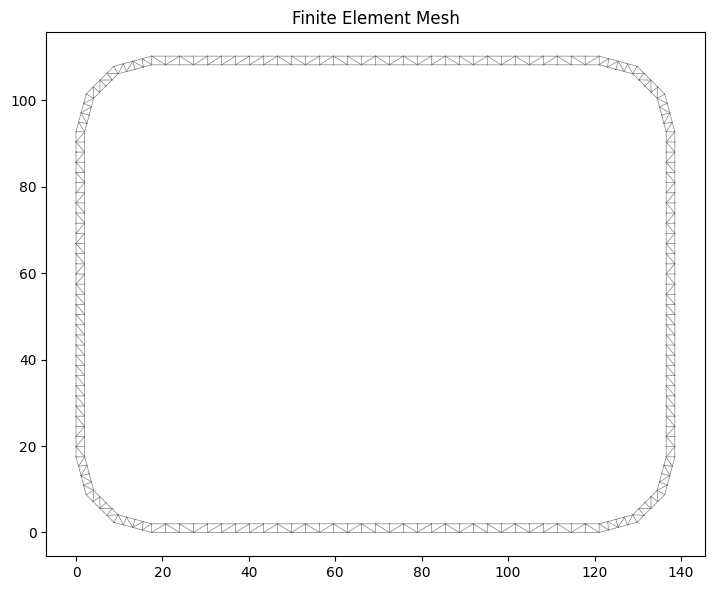

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
section.plot_mesh(ax=ax, materials=False)
plt.show()